In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

#Raw Version
df_lter = pd.read_csv(r"C:\Users\suhan\Downloads\archive (5)\penguins_lter.csv")

In [5]:
#Cleaning Raw Data For Seeing The Data I took EDA Earlier to Know About the data
df_lter.head()
df_lter.shape
df_lter.columns
df_lter.info()
df_lter.describe()
df_lter.describe(include="object")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    object 
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    object 
 3   Region               344 non-null    object 
 4   Island               344 non-null    object 
 5   Stage                344 non-null    object 
 6   Individual ID        344 non-null    object 
 7   Clutch Completion    344 non-null    object 
 8   Date Egg             344 non-null    object 
 9   Culmen Length (mm)   342 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12  Body Mass (g)        342 non-null    float64
 13  Sex                  334 non-null    object 
 14  Delta 15 N (o/oo)    330 non-null    float64
 15  Delta 13 C (o/oo)    331 non-null    flo

,studyName,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Sex,Comments
count,344,344,344,344,344,344,344,344,334,26
unique,3,3,1,3,1,190,2,50,3,7
top,PAL0910,Adelie Penguin (Pygoscelis adeliae),Anvers,Biscoe,"Adult, 1 Egg Stage",N61A2,Yes,11/27/07,MALE,Nest never observed with full clutch.
freq,120,152,344,168,344,3,308,18,168,13


In [6]:
df_lter.isnull().sum()

studyName                0
Sample Number            0
Species                  0
Region                   0
Island                   0
Stage                    0
Individual ID            0
Clutch Completion        0
Date Egg                 0
Culmen Length (mm)       2
Culmen Depth (mm)        2
Flipper Length (mm)      2
Body Mass (g)            2
Sex                     10
Delta 15 N (o/oo)       14
Delta 13 C (o/oo)       13
Comments               318
dtype: int64

In [7]:
df_lter.duplicated().sum()

np.int64(0)

In [8]:
df_lter.nunique()

studyName                3
Sample Number          152
Species                  3
Region                   1
Island                   3
Stage                    1
Individual ID          190
Clutch Completion        2
Date Egg                50
Culmen Length (mm)     164
Culmen Depth (mm)       80
Flipper Length (mm)     55
Body Mass (g)           94
Sex                      3
Delta 15 N (o/oo)      330
Delta 13 C (o/oo)      331
Comments                 7
dtype: int64

In [9]:
df_lter.dtypes

studyName               object
Sample Number            int64
Species                 object
Region                  object
Island                  object
Stage                   object
Individual ID           object
Clutch Completion       object
Date Egg                object
Culmen Length (mm)     float64
Culmen Depth (mm)      float64
Flipper Length (mm)    float64
Body Mass (g)          float64
Sex                     object
Delta 15 N (o/oo)      float64
Delta 13 C (o/oo)      float64
Comments                object
dtype: object

In [10]:
#Cleaning The Data Changing For consistent, lowercase, snake_case names avoid bugs
df_lter = df_lter.rename(columns={
    'Culmen Length (mm)': 'bill_length_mm',
    'Culmen Depth (mm)': 'bill_depth_mm',
    'Flipper Length (mm)': 'flipper_length_mm',
    'Body Mass (g)': 'body_mass_g',
    'Sex': 'sex',
    'Island': 'island',
    'Species': 'species'
})

In [11]:
df_lter['species'].unique()

array(['Adelie Penguin (Pygoscelis adeliae)',
       'Chinstrap penguin (Pygoscelis antarctica)',
       'Gentoo penguin (Pygoscelis papua)'], dtype=object)

In [12]:
df_lter['species'] = df_lter['species'].str.split(' ').str[0]

In [13]:
df_lter['sex'].unique()

array(['MALE', 'FEMALE', nan, '.'], dtype=object)

In [14]:
df_lter['sex'] = df_lter['sex'].replace({'MALE':'Male', 'FEMALE':'Female'})
df_lter.loc[~df_lter['sex'].isin(['Male','Female']), 'sex'] = np.nan

In [15]:
drop_cols = ['studyName', 'Sample Number', 'Region', 'Stage', 'Individual ID',
             'Clutch Completion', 'Date Egg', 'Comments',
             'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)']
df_lter = df_lter.drop(columns=drop_cols)

In [16]:
df_lter = df_lter[['species','island','bill_length_mm','bill_depth_mm',
                    'flipper_length_mm','body_mass_g','sex']]
print(df_lter.shape) 

(344, 7)


In [17]:
#EDA Process After Cleaning Data
df_lter.shape
df_lter.info()
df_lter.describe()
df_lter.describe(include='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


,species,island,sex
count,344,344,333
unique,3,3,2
top,Adelie,Biscoe,Male
freq,152,168,168


<Axes: >

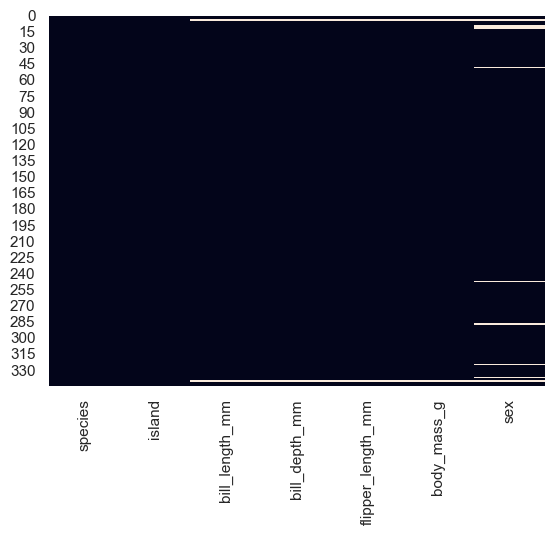

In [18]:
df_lter.isnull().sum()
sns.heatmap(df_lter.isnull(), cbar=False)

In [19]:
df_lter = df_lter.dropna(subset=['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g'])
df_lter['sex'] = df_lter['sex'].fillna('Unknown') 

<Axes: xlabel='species', ylabel='count'>

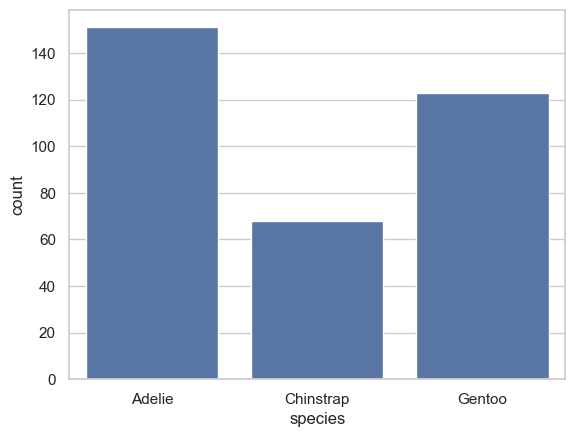

In [20]:
df_lter['species'].value_counts()
df_lter['species'].value_counts(normalize=True) * 100
sns.countplot(x='species', data=df_lter)

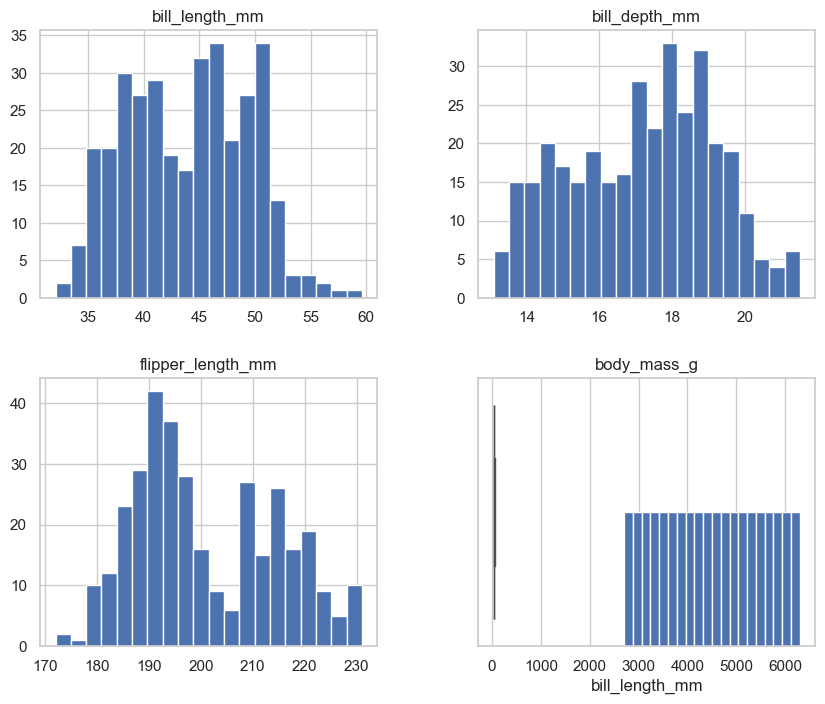

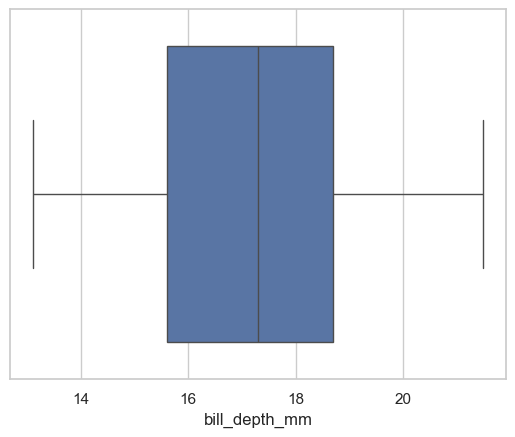

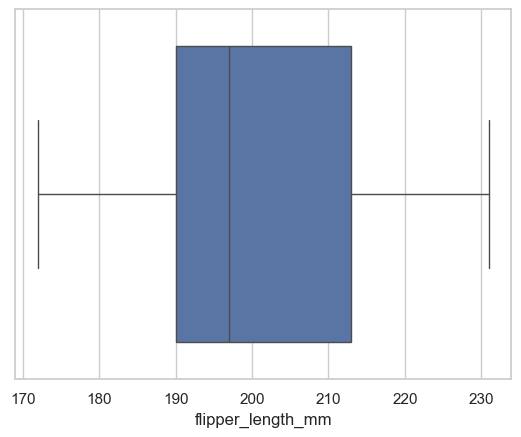

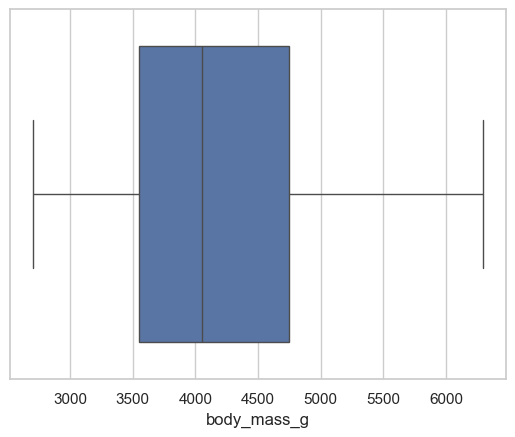

In [21]:
num_cols = ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']
df_lter[num_cols].hist(bins=20, figsize=(10,8))

for col in num_cols:
    sns.boxplot(x=df_lter[col]); plt.show()

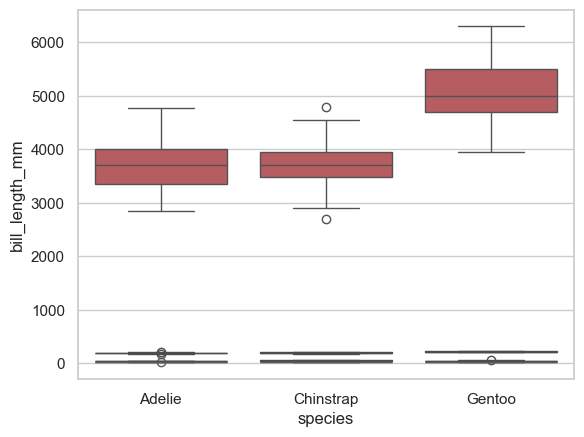

In [22]:
for col in num_cols:
    sns.boxplot(x='species', y=col, data=df_lter)

In [23]:
#IQR method for true outliers (within group):
def iqr_outliers(group, col):
    Q1, Q3 = group[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return group[(group[col] < Q1-1.5*IQR) | (group[col] > Q3+1.5*IQR)]

for sp in df_lter['species'].unique():
    sub = df_lter[df_lter['species']==sp]
    for col in num_cols:
        out = iqr_outliers(sub, col)
        print(sp, col, len(out))

Adelie bill_length_mm 0
Adelie bill_depth_mm 1
Adelie flipper_length_mm 2
Adelie body_mass_g 0
Chinstrap bill_length_mm 0
Chinstrap bill_depth_mm 0
Chinstrap flipper_length_mm 0
Chinstrap body_mass_g 2
Gentoo bill_length_mm 1
Gentoo bill_depth_mm 0
Gentoo flipper_length_mm 0
Gentoo body_mass_g 0


<Axes: >

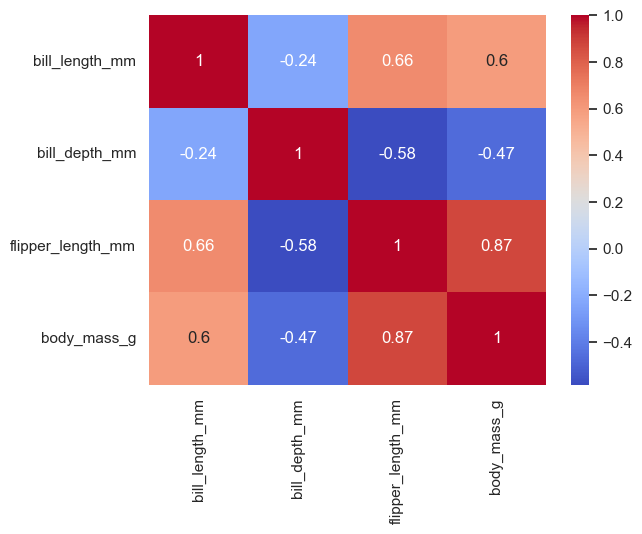

In [24]:
#Bivariate/Multivariate Analysis
sns.heatmap(df_lter[num_cols].corr(), annot=True, cmap='coolwarm')

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

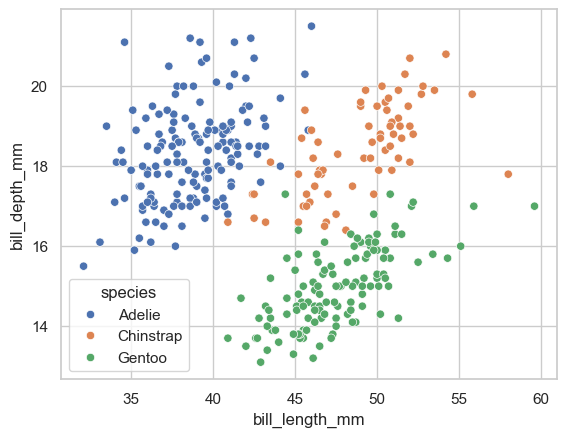

In [25]:
sns.scatterplot(x='bill_length_mm', y='bill_depth_mm', hue='species', data=df_lter)


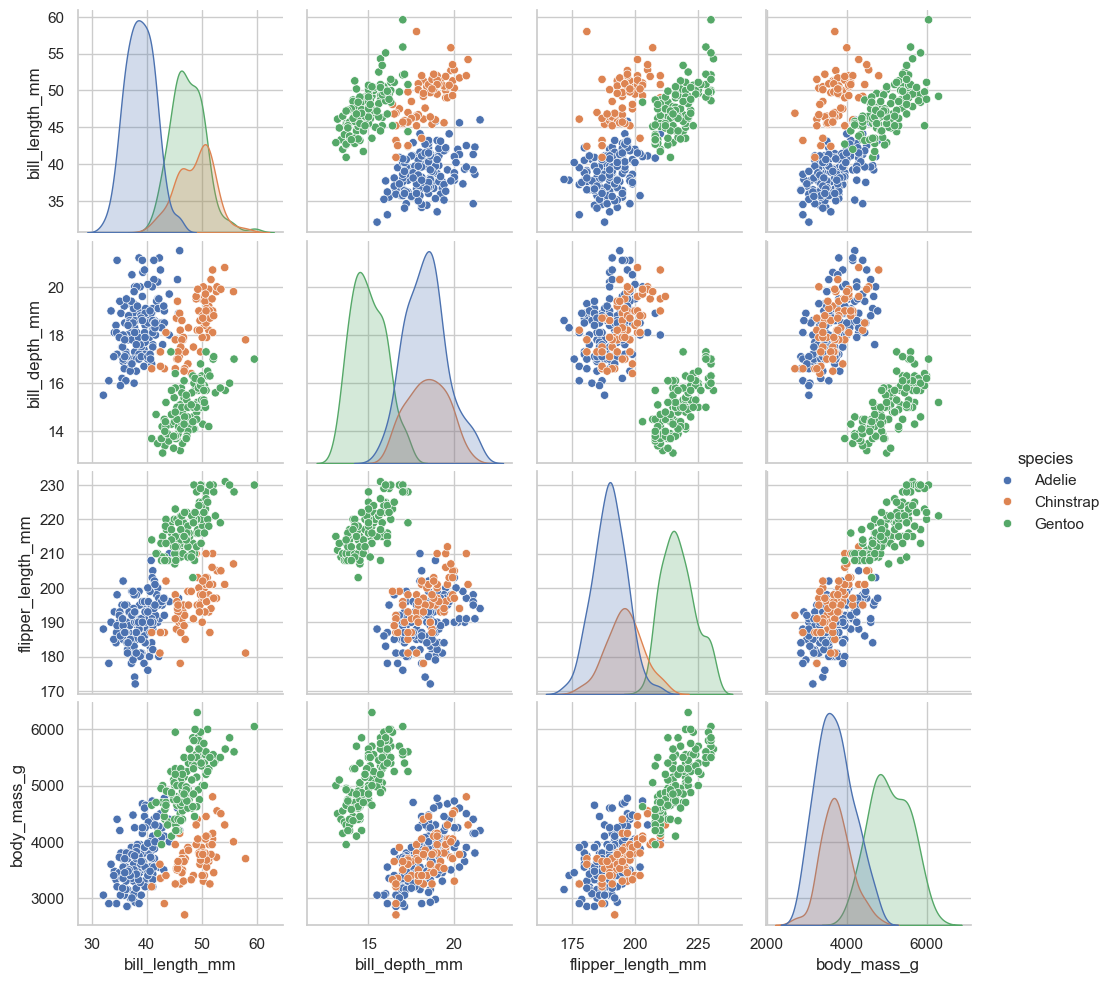

In [26]:
sns.pairplot(df_lter, hue='species', vars=num_cols)

<Axes: xlabel='island', ylabel='count'>

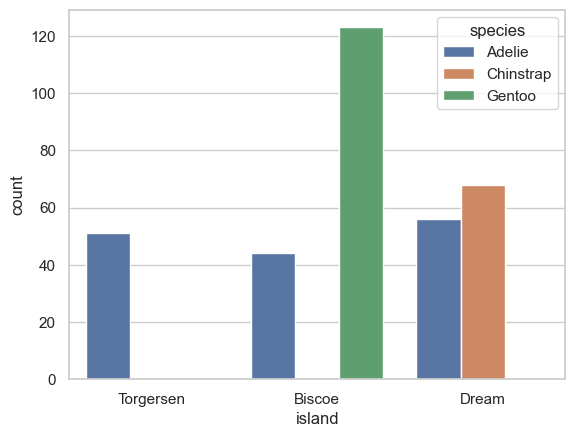

In [27]:
#Categorical Relationship
pd.crosstab(df_lter['island'], df_lter['species'])
sns.countplot(x='island', hue='species', data=df_lter)

In [28]:
#Skewness Check
df_lter[num_cols].skew()

bill_length_mm       0.053118
bill_depth_mm       -0.143465
flipper_length_mm    0.345682
body_mass_g          0.470329
dtype: float64

In [29]:
#Preprocessing for Modeling

In [30]:
#Encoding Categorical Variables
df_enc = pd.get_dummies(df_lter, columns=['island','sex'], drop_first=True)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_enc['species_enc'] = le.fit_transform(df_lter['species'])

X = df_enc.drop(columns=['species','species_enc'])

y = df_enc['species_enc']

In [32]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                       random_state=42, stratify=y)

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])   # transform only, never fit again


In [33]:
#Model Building
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix,
                              precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel='rbf', probability=True),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200),
    "Naive Bayes": GaussianNB(),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, preds))

Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 0.9855072463768116
KNN Accuracy: 1.0
SVM (RBF) Accuracy: 1.0
Random Forest Accuracy: 1.0
Naive Bayes Accuracy: 0.8260869565217391


<Axes: >

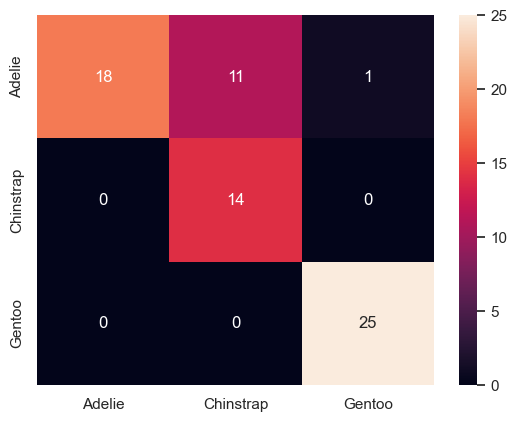

In [34]:
#Confusion Matrix
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)

In [35]:
#Core Metrics (multi-class, per-class then averaged)
print(classification_report(y_test, preds, target_names=le.classes_))

              precision    recall  f1-score   support

      Adelie       1.00      0.60      0.75        30
   Chinstrap       0.56      1.00      0.72        14
      Gentoo       0.96      1.00      0.98        25

    accuracy                           0.83        69
   macro avg       0.84      0.87      0.82        69
weighted avg       0.90      0.83      0.83        69



In [36]:
#Cross-Validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(cv_scores, cv_scores.mean())

[0.97101449 0.79710145 0.88235294 0.91176471 0.72058824] 0.8565643648763853


In [38]:
#ROC-AUC (for probabilistic/binary-style evaluation)
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0,1,2])
probs = model.predict_proba(X_test)
roc_auc_score(y_test_bin, probs, multi_class='ovr')

0.9978465978465979

In [39]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)
print(f"Train: {train_acc:.3f}  Test: {test_acc:.3f}")

Train: 0.802  Test: 0.826


In [40]:
#Hyperparameter Tuning
param_grid = {'n_estimators':[100,200,300], 'max_depth':[None,5,10]}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
print(grid.best_params_, grid.best_score_)

{'max_depth': None, 'n_estimators': 100} 0.9926599326599327


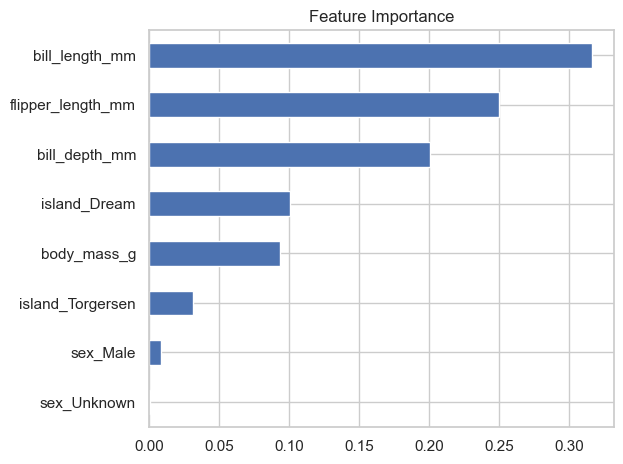

In [46]:
#Feature Importance / Interpretability
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()